# NPUWattch hands-on — 2. Timeloop: an Eyeriss-like accelerator running AlexNet

This is the basic Timeloop example. The design is an Eyeriss-like accelerator
with a 14×12 array of int8 PEs, a 128 KB global buffer, and LPDDR4 DRAM. The
workload is all eight layers of AlexNet, one `timeloop-mapper` stats file per
layer.

The example folder has:

```
timeloop/eyeriss_like/
├── arch.yaml                   the Accelergy v0.4 architecture, the same file Timeloop reads
├── compound_components.yaml    NPUWattch definition file 1: a class made of several primitives
├── projection.yaml             NPUWattch definition file 2: Timeloop events -> compound elements
├── user_components.yaml        NPUWattch definition file 3: cost of custom blocks
└── alexnet/
    ├── stats/01_conv1.stats.txt ... 08_fc8.stats.txt
    ├── run                     the command
    └── out/                    report.html, report.json (written by ./run)
```

The command in `run` is:

```bash
npuwattch --harness timeloop --arch-yaml ../arch.yaml --stats stats/ \
          --node 7nm --clock-mhz 1000 --tree --report out/
```


In [1]:
import sys; sys.path.insert(0, ".")
from tutorial_helpers import *
import pandas as pd
pd.set_option("display.width", 160); pd.set_option("display.max_colwidth", 60)
print("npuwattch:", npuwattch_binary())

npuwattch: /home/KNUEEhdd1/ys_knu/kmk/miniforge3/envs/npuwattch/bin/npuwattch


## 1. Run it, and read the tree first

The run takes a few seconds. The first thing to look at is the instance tree:
the hardware as NPUWattch understood it from `arch.yaml`.

In [2]:
ex = example("timeloop/eyeriss_like/alexnet")
text = run(ex)
show_tree(text)

INFO (NW-1001): Instance hierarchy (declared in the Accelergy description):


Three things to check in the tree:

- **Six components**: `DRAM`, `shared_glb`, three per-PE scratchpads, and `mac`.
  They are the six `!Component` nodes of `arch.yaml`.
- **`[×168]`** on the scratchpads and the MAC. The `!Container` nodes
  `PE_column` (`meshX: 14`) and `PE` (`meshY: 12`) above them multiply out to
  168 instances.
- **The sizes** at the end of each line: `shared_glb` is 128 KB, the weight
  scratchpad is 384 B per PE. If a size is wrong here, every number after it
  is wrong too, so this is the place to catch a mistake in the architecture
  file.

## 2. The messages

Every assumption NPUWattch makes is printed. This run has no WARNING lines.
The INFO lines tell you what was taken from a convention rather than from your
file. (The PyTorchSim run in notebook 1 had WARNING lines as well. The
difference is that this architecture file states every size and port count
NPUWattch needs.)

In [3]:
show_messages(text, kinds=("WARNING", "INFO"))

INFO (NW-1026): Harness mode: timeloop
INFO (NW-1301): NPUWattch builds the description database from ../arch.yaml.
INFO (NW-1303): The description database has 6 components with 674 instances in total.
INFO (NW-1001): Instance hierarchy (declared in the Accelergy description):
INFO (NW-7403): system_top_level.DRAM (DRAM type LPDDR4): 8 pJ/bit from the shipped table lpddr4.yml.
INFO (NW-7301): system_top_level.DRAM (hbm): NPUWattch ignores the Accelergy attribute(s) datawidth.
INFO (NW-7306): system_top_level.eyeriss.shared_glb (sram): depth 16384 is the total of 32 banks, so mem_depth_per_bank is 512 (128 KB total).
INFO (NW-7307): system_top_level.eyeriss.shared_glb (sram): no port count is declared, so NPUWattch uses one shared read-write port.
INFO (NW-7308): system_top_level.eyeriss.shared_glb (sram): bandwidth 16 words/cycle (8 words per access) gives up to 2 bank accesses per cycle.
INFO (NW-7301): system_top_level.eyeriss.shared_glb (sram): NPUWattch ignores the Accelergy attri

What they mean:

- `NW-7306`, `depth 16384 is the total of 32 banks, so mem_depth_per_bank is
  512`: Accelergy's `depth` is the whole buffer; NPUWattch's SRAM model works per
  bank. The harness converted it and tells you the result (128 KB in total).
- `NW-7307`, `no port count is declared, so NPUWattch uses one shared
  read-write port`: the buffer has no `n_rw_ports` in `arch.yaml`, so one port is assumed, and the
  port count is checked against the bandwidth the mapping needs.
- `NW-7403`, `8 pJ/bit from the shipped table lpddr4.yml`: the DRAM cost comes from the
  table for the Accelergy `type: LPDDR4`. Notebook 4 swaps in a different
  table.
- `NW-2116`, `User component ... is in the library, but the run does not use
  it`, and `NW-7101`, `Compound component 'counter' ... is parsed, but no
  component uses it`: the definition files contain an example compound
  (`counter`) and an example user component that this design does not use.
  Nothing to do.
- `NW-1902`, `Message summary: 0 CRITICAL, 0 ERROR, 0 WARNING, 25 INFO.`: the
  last message of every run.


## 3. One window per layer

`--stats stats/` is a directory, so each stats file becomes one **window** in
the report, in file-name order. That is why the files are named `01_`...`08_`.

,window,cycles,dynamic,leakage,total
0,01_conv1,638880,663 µJ,1.87 µJ,665 µJ
1,02_conv2,2332800,2.69e+03 µJ,6.84 µJ,2.7e+03 µJ
2,03_conv3,718848,1.13e+03 µJ,2.11 µJ,1.14e+03 µJ
3,04_conv4,1437696,1.47e+03 µJ,4.22 µJ,1.48e+03 µJ
4,05_conv5,638976,974 µJ,1.87 µJ,976 µJ
5,06_fc6,393216,2.97e+03 µJ,1.15 µJ,2.97e+03 µJ
6,07_fc7,262144,1.32e+03 µJ,769 nJ,1.32e+03 µJ
7,08_fc8,40960,322 µJ,120 nJ,322 µJ


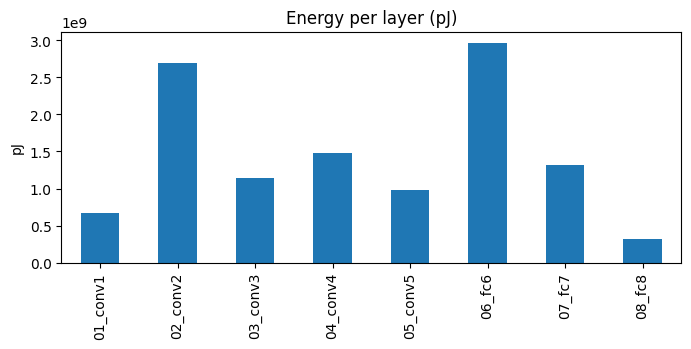

In [4]:
rep = report(ex)
w = windows_df(rep)
display(w.drop(columns="total_pJ"))
ax = w.plot.bar(x="window", y="total_pJ", legend=False, figsize=(8, 3), title="Energy per layer (pJ)")
ax.set_xlabel(""); ax.set_ylabel("pJ");

The convolution layers dominate; the three fully connected layers at the end
are small in compute but, as you will see in the component table, heavy in
DRAM traffic.

## 4. Where the energy went

In [5]:
display(components_df(rep))
show_totals(text)

,component,class,model,instances,energy,share %,area
0,system_top_level.DRAM,hbm,const,1,4.61e+03 µJ,39.8,n/a
1,system_top_level.eyeriss.PE_column.PE.weights_spad,regfile,cal,168,4.59e+03 µJ,39.7,1.52e+03
2,system_top_level.eyeriss.PE_column.PE.psum_spad,regfile,cal,168,1.56e+03 µJ,13.5,122
3,system_top_level.eyeriss.PE_column.PE.mac,intmac,cal,168,469 µJ,4.1,55.7
4,system_top_level.eyeriss.PE_column.PE.ifmap_spad,regfile,cal,168,315 µJ,2.7,92.9
5,system_top_level.eyeriss.shared_glb,sram,cal,1,12.8 µJ,0.1,1.59e+05


total energy = 1.156e+10 pJ (dyn 1.154e+10 + leak 1.895e+07); avg power = 1788 mW; exec = 0.006464 s
calibrated primitives available: fpadd, fpmul, fpmac, intadd, intmul, intmac, fpsfu, mxfpmac, fifo, regfile, simplemux, crossbar, fattree, foldedclos, sram


Expected result at 7 nm, 1 GHz:

| | |
| --- | --- |
| Total energy | about 11.6 mJ for the eight layers |
| Area | 0.459 mm² |
| On-chip energy per MAC | about 16 pJ |
| DRAM share | about 40% |

The `model` column says where each number came from: `cal` is a trained model,
`const` is a cost table (the DRAM). Every row here is one or the other.

## 5. Try it: one number instead of eight windows

`--stats-mode aggregate` sums the eight files into one window. The total is
the same; only the per-window view changes.

In [6]:
text_agg = run(ex, "--stats-mode", "aggregate", log_name="console_aggregate.txt")
print("windows:", len(report(ex)["windows"]))
show_totals(text_agg)
print()
print("same total as the windowed run:", abs(total_energy_pJ(text_agg) - total_energy_pJ(text)) / total_energy_pJ(text) < 1e-6)
_ = run(ex)   # put the eight-window report back

windows: 1
total energy = 1.156e+10 pJ (dyn 1.154e+10 + leak 1.895e+07); avg power = 1788 mW; exec = 0.006464 s
calibrated primitives available: fpadd, fpmul, fpmac, intadd, intmul, intmac, fpsfu, mxfpmac, fifo, regfile, simplemux, crossbar, fattree, foldedclos, sram

same total as the windowed run: True


## 6. The HTML report

`out/report.html` is a single self-contained page. From top to bottom: the
totals, the energy and area breakdown charts, the DRAM breakdown, the energy
across windows, the component table, the instance tree, and a provenance
section that lists every input file and every message of the run. The same
numbers are in `out/report.json` for scripts (that is what the tables above
came from).

In [7]:
show_report(ex)

## Messages you will see, and what to do

**Every time.** The INFO lines in section 2. None of them needs action.

**If something looks wrong:**

| What you see | What it means | What to do |
| --- | --- | --- |
| `WARNING (NW-7219): Stats level(s) with no matching description component: X` | A level in the stats file has a name that is not a component name | Add a `stats_map.yaml` with `levels: {X: <component>}` and pass `--stats-map`, or list it under `ignore:` |
| `WARNING (NW-7114): N component(s) have no NPUWattch primitive and are not modeled: ...` | An Accelergy `class` NPUWattch does not know | Define the class as a compound in `compound_components.yaml`, or add it to `user_components.yaml` |
| `ERROR (NW-5101): projection.yaml is not in <dir>, and --projection is not given.` | A definition file is missing | Copy the three files from `timeloop/eyeriss_like/` next to your `arch.yaml`, or pass `--projection` |
| `WARNING (NW-7309): ... bandwidth N words/cycle needs M accesses/cycle, but ... give ...` | The mapping needs more ports than the buffer declares | Add `n_rd_ports` / `n_wr_ports` to the buffer in `arch.yaml`, as `psum_spad` does here |
| `npuwattch: command not found` | NPUWattch is not installed in this environment | `cd NPUWattch && pip install -e .` |

Next: `03_timeloop_gemmini_vs_nvdla.ipynb`.
